#Exp 6: Credit Risk Assessment:
Build a credit scoring model to assess
the creditworthiness of applicants using historical financial data and
perform comparative analysis (Logistic Regression, Random Forest,
XGBoost)

#Dataset Loading and Exploration

In [1]:
!pip install -q scikit-learn pandas numpy matplotlib seaborn xgboost imbalanced-learn
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
print("Credit risk models ready!")


Credit risk models ready!


#Load Dataset

In [2]:
csv_path = '/content/drive/MyDrive/AML_Lab_B19/Exp-6 Credit Risk Assessment/credit_risk_assessment_500_samples.csv'
df = pd.read_csv(csv_path)
print(f"Loaded: {df.shape}")
print("Columns:", df.columns.tolist())
print(df.head())
print("\nTarget distribution:\n", df.iloc[:,-1].value_counts(normalize=True))  # Last col target


Loaded: (500, 11)
Columns: ['Applicant_ID', 'Age', 'Annual_Income', 'Employment_Years', 'Credit_Score', 'Loan_Amount', 'Loan_Term_Months', 'Existing_Loans_Count', 'Debt_to_Income_Ratio', 'Late_Payments_Last_2Yrs', 'Credit_Risk']
   Applicant_ID  Age  Annual_Income  Employment_Years  Credit_Score  \
0             1   59         153267                28           818   
1             2   49         232745                 0           436   
2             3   35         974945                19           797   
3             4   63         307164                29           776   
4             5   28         685626                 6           893   

   Loan_Amount  Loan_Term_Months  Existing_Loans_Count  Debt_to_Income_Ratio  \
0       196649                12                     2                  0.68   
1       175354                60                     0                  0.23   
2       662297                48                     3                  0.54   
3       831725          

#Preprocess (Auto Numeric/Cat + Encode)

In [4]:
target_col = df.columns[-1]
X = df.drop(target_col, axis=1)
y = df[target_col] # y is currently a Series of strings ('High', 'Medium', 'Low')

# Encode categoricals in X
cat_cols = X.select_dtypes(include=['object']).columns
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# Fill NaN in X
X = X.fillna(X.median())

high_risk_rate = (y == 'High').mean()

# Now, encode the target variable 'y' to numerical values for model training.
# This will replace the string labels in 'y' with numerical ones (e.g., 0, 1, 2).
le_y = LabelEncoder()
y_encoded_values = le_y.fit_transform(y)
# Replace the original 'y' Series with the encoded numerical Series
y = pd.Series(y_encoded_values, index=y.index, name=y.name)


print(f"Processed: {X.shape}, High Risk Rate: {high_risk_rate:.4f}")

# Scale numeric in X
scaler = StandardScaler()
num_cols = X.select_dtypes(include=[np.number]).columns
X[num_cols] = scaler.fit_transform(X[num_cols])

Processed: (500, 10), High Risk Rate: 0.6300


#Train-Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
print(f"Train: {X_train.shape}, Test bad rate: {y_test.mean():.4f}")


Train: (350, 10), Test bad rate: 0.6933


#Train Models

In [6]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"Trained {name}")


Trained Logistic Regression
Trained Random Forest
Trained XGBoost


#Predictions & Metrics

In [8]:
metrics = {}
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    # Get probabilities for all classes, not just one
    y_prob = model.predict_proba(X_test)

    # Calculate multi-class AUC (One-vs-Rest strategy)
    # `labels` ensures correct class order for AUC calculation based on LabelEncoder
    auc = roc_auc_score(y_test, y_prob, multi_class='ovr', labels=le_y.transform(le_y.classes_))

    # Calculate precision, recall, F1-score for multi-class (using 'weighted' average)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

    metrics[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': auc
    }

    # Use target_names for clearer classification report in multi-class setting
    print(f"\n{name}:\n{classification_report(y_test, y_pred, target_names=le_y.classes_)}")

df_metrics = pd.DataFrame(metrics).T.round(4)
print("\nCredit Scoring Comparison:\n", df_metrics)


Logistic Regression:
              precision    recall  f1-score   support

        High       0.86      0.85      0.86        95
         Low       0.80      0.67      0.73         6
      Medium       0.69      0.71      0.70        49

    accuracy                           0.80       150
   macro avg       0.78      0.74      0.76       150
weighted avg       0.80      0.80      0.80       150


Random Forest:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00        95
         Low       1.00      0.33      0.50         6
      Medium       0.92      1.00      0.96        49

    accuracy                           0.97       150
   macro avg       0.97      0.78      0.82       150
weighted avg       0.98      0.97      0.97       150


XGBoost:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00        95
         Low       1.00      0.83      0.91         6
      Medium       0.98    

#Visuals & Feature Importance

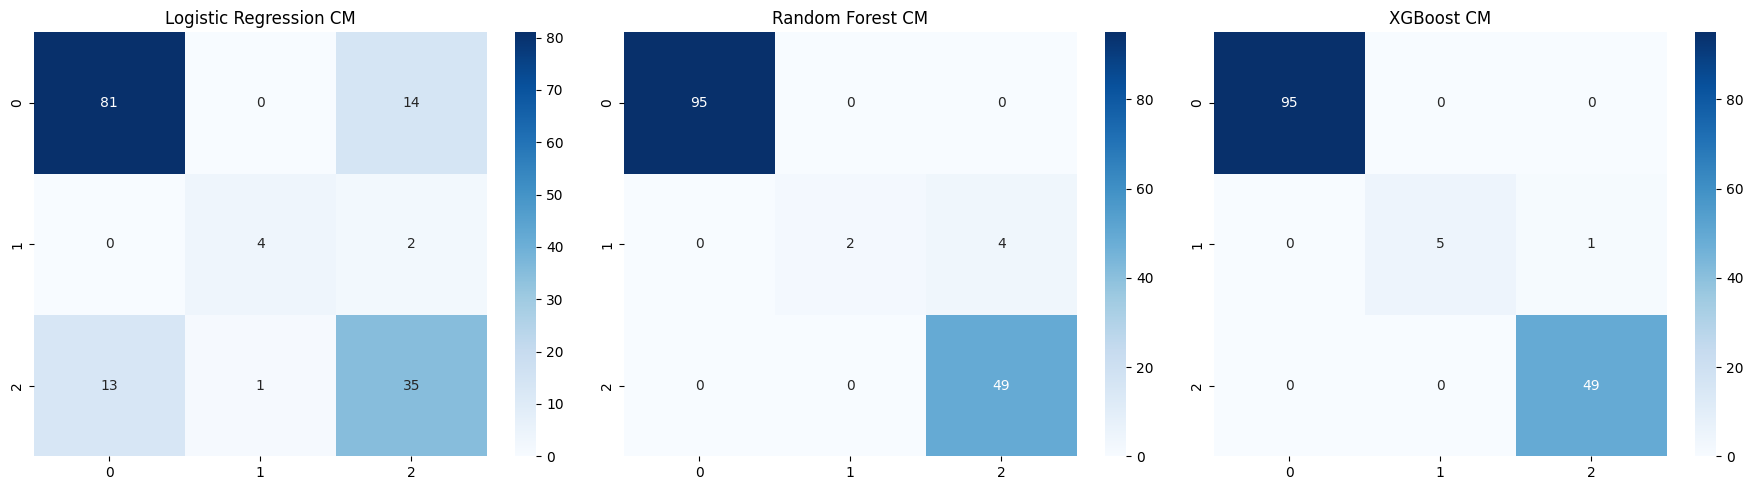

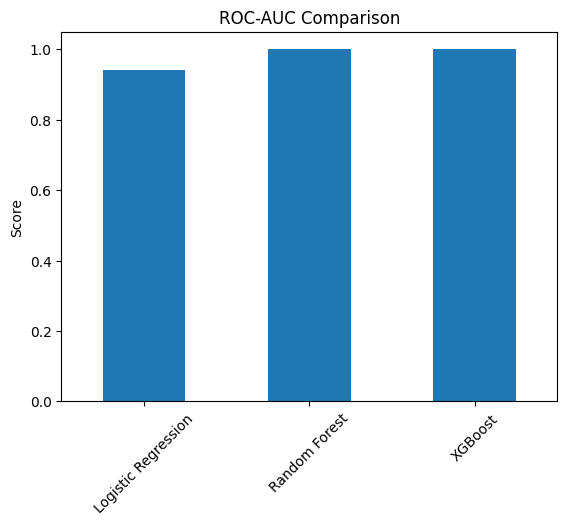

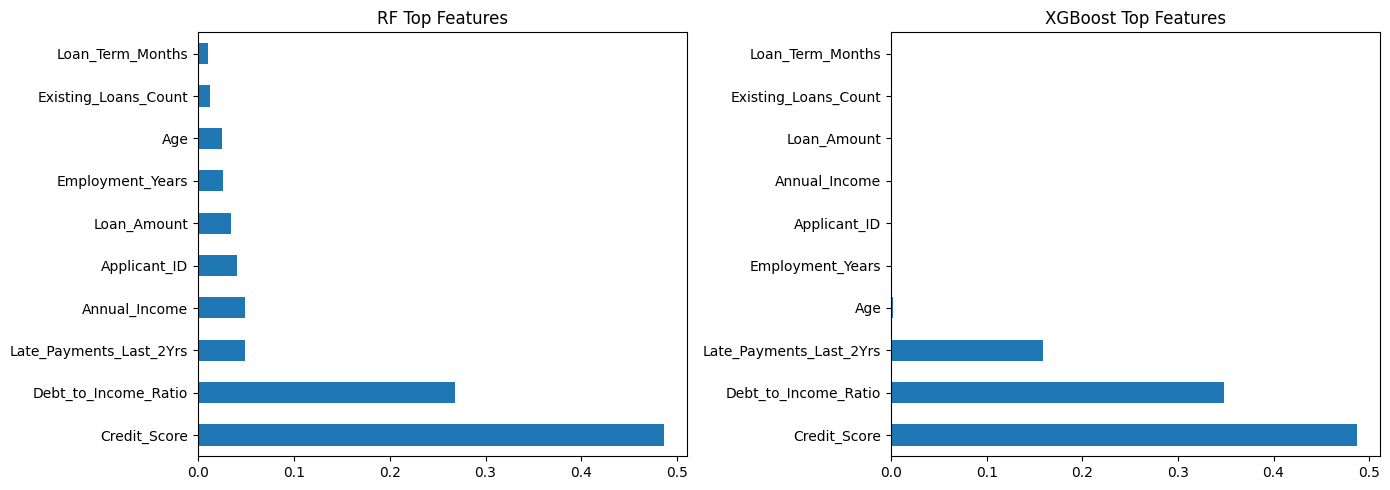

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, name in enumerate(trained_models):
    cm = confusion_matrix(y_test, trained_models[name].predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'{name} CM')

plt.tight_layout(); plt.show()

# AUC Bar
df_metrics['ROC-AUC'].plot(kind='bar')
plt.title('ROC-AUC Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.show()

# RF/XGB Feature Importances (top 10)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
feat_rf = pd.Series(trained_models['Random Forest'].feature_importances_, index=X.columns).nlargest(10)
feat_xgb = pd.Series(trained_models['XGBoost'].feature_importances_, index=X.columns).nlargest(10)
feat_rf.plot.barh(ax=axes[0], title='RF Top Features')
feat_xgb.plot.barh(ax=axes[1], title='XGBoost Top Features')
plt.tight_layout(); plt.show()
